# Fractional vaccine dosing review: descriptive statistics and figures

This notebook is designed to produce **manuscript-ready descriptive summaries** from the extraction CSV using a **two-axis framework**:

## Axis 1: comparison type
- `Formal NI / equivalence`
- `Comparative, not formal NI`
- `Follow-up / persistence`
- `Single-arm / implementation`
- `Secondary review / background`

## Axis 2: finding direction
- `Supportive`
- `Non-supportive`
- `Mixed`
- `Not assessable`

This is cleaner than forcing everything into one NI bucket!

By default it looks for:

`Dataset_Extraction.csv.csv`

Change the filename in the loading cell if needed :)

In [1]:
# Imports
from pathlib import Path
import re

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 180)


In [2]:
# Paths
BASE_DIR = Path(".")

INPUT_CANDIDATES = [
    ("Dataset_Extraction.xlsx", "excel", {"sheet_name": "Extraction"}),
    ("Dataset_Extraction.csv", "csv", {}),
    ("Fractional Vaccines_Extraction.csv", "csv", {}),
]

SOURCE_PATH = None
SOURCE_KIND = None
SOURCE_READ_KWARGS = {}

for filename, kind, read_kwargs in INPUT_CANDIDATES:
    candidate = BASE_DIR / filename
    if candidate.exists():
        SOURCE_PATH = candidate
        SOURCE_KIND = kind
        SOURCE_READ_KWARGS = read_kwargs
        break

if SOURCE_PATH is None:
    searched = "\n".join(f"- {(BASE_DIR / name).resolve()}" for name, _, _ in INPUT_CANDIDATES)
    raise FileNotFoundError(
        "No input file found. Place one of the following in the notebook folder:\n" + searched
    )

OUTPUT_DIR = BASE_DIR / "outputs_two_axis"
TABLE_DIR = OUTPUT_DIR / "tables"
FIG_DIR = OUTPUT_DIR / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Using {SOURCE_KIND} source: {SOURCE_PATH.resolve()}")
if SOURCE_KIND == "excel":
    print(f"Reading sheet: {SOURCE_READ_KWARGS.get('sheet_name', 'Sheet1')}")
print(f"Outputs will be saved in: {OUTPUT_DIR.resolve()}")


Using csv source: /Users/oliviawilko/Documents/Data Science/Global Helth/Impact First/Dataset_Extraction.csv
Outputs will be saved in: /Users/oliviawilko/Documents/Data Science/Global Helth/Impact First/outputs_two_axis


In [3]:
# Load data
if SOURCE_KIND == "excel":
    df = pd.read_excel(SOURCE_PATH, **SOURCE_READ_KWARGS)
elif SOURCE_KIND == "csv":
    df = pd.read_csv(SOURCE_PATH, **SOURCE_READ_KWARGS)
else:
    raise ValueError(f"Unsupported source kind: {SOURCE_KIND}")

print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")
display(df.head(3))


Rows: 103
Columns: 38


,Study ID,Publication year,Short citation,Title,Authors,Journal / source,DOI,URL,Vaccine / intervention,Pathogen / disease,Population age group,Special population,Country / setting,Study design,Route of administration,Outcome domains,Follow-up paper?,Comparator (full dose / standard / other),Fractional / reduced dose arm(s),Schedule / timing,Sample size randomized,Sample size analyzed,Primary endpoint,Immunogenicity endpoint,Clinical endpoint,Safety endpoint,Non-inferiority margin,NI result,Key numerical result(s),Meta-analysis usable?,Reason not meta-analyzable,Data extraction notes,Screening note,Abstract,TL;DR / study gist,Original abstract,Source depth,Sources checked
0,S001,2026,"Lee et al., 2026",Adverse events following immunization (AEFI) with fractional one-fifth and one-half doses of yellow fever vaccine compared to standard dose in children 9-23 months old in Ugand...,"Lee, Scarlett E.; Najjengo, Marjorie; Shaum, Anna; Sekiziyivu, Arthur B.; Carlock, Grace; Casey, Rebecca M.; Lubega, Irene; Tumwine, Conrad; Twinomuhwezi-Oyet, Ellon; Nakato, W...",Vaccine,10.1016/j.vaccine.2025.128131,https://pubmed.ncbi.nlm.nih.gov/41512502/,Bio-Manguinhos 17DD yellow fever vaccine,Yellow fever virus / yellow fever,Infants / toddlers (9-23 months),Children under 2 years,Uganda (3 sites),Single-blind randomized controlled trial (final safety report),Subcutaneous (not explicitly stated in abstract; verify full text),Safety / reactogenicity,Yes - final safety report from same trial family,Full / standard dose,1/2 dose and 1/5 dose,Single yellow fever dose; active safety surveillance for 28 days,1770,1770 for safety follow-up (AEFI ascertainment),Occurrence of adverse events following immunization within 28 days,Not the focus of this paper,None reported,Non-serious and serious AEFI/SAE within 28 days; causality review for serious events,Not applicable,Not applicable - safety report,1066/1770 (60%) had >=1 non-serious AE; 30/1770 (1.7%) had a serious AE; no safety difference by arm; 3 SAEs judged vaccine-product-related; 6 deaths occurred but none were cau...,No,Safety-only report without a comparative immunogenicity endpoint suitable for pooling.,TL;DR based on PubMed abstract. Route needs full-text confirmation. Sources: https://pubmed.ncbi.nlm.nih.gov/41512502/ ; DOI https://doi.org/10.1016/j.vaccine.2025.128131,Safety-only final report linked to a pediatric yellow fever fractional-dose trial.,"BACKGROUND: Lacking adequate safety data, the World Health Organization (WHO) recommends a full dose of yellow fever (YF) vaccine to children two years or younger. In older age...","Final safety analysis of a Ugandan randomized trial in children 9-23 months comparing full, half, and one-fifth yellow fever vaccine doses. Adverse events were common but mostl...",NaN,Abstract/web,https://pubmed.ncbi.nlm.nih.gov/41512502/ ; DOI https://doi.org/10.1016/j.vaccine.2025.128131
1,S002,2026,"Kimathi et al., 2026","Low-dose yellow fever vaccination in infants: a randomised, double-blind, non-inferiority trial","Kimathi, Derick; Juan-Giner, Aitana; Bob, Ndeye S.; Orindi, Benedict; Namulwana, Maria L.; Diatta, Antoine; Cheruiyot, Stanley; Fall, Gamou; Dia, Moussa; Hamaluba, Mainga M.; N...",Lancet,10.1016/S0140-6736(25)02069-0,https://pubmed.ncbi.nlm.nih.gov/41544642/,Institut Pasteur de Dakar 17D-204 yellow fever vaccine,Yellow fever virus / yellow fever,Infants (9-12 months),Co-administered with measles-rubella vaccine,Kenya and Uganda (2 centres),Randomized double-blind non-inferiority trial,Not stated in abstract - verify full text,Immunogenicity; safety/reactogenicity,No,"Standard dose (>13,000 IU)",500 IU fractional dose,Single YF dose with concomitant measles-rubella vaccine; primary endpoint at day 28,420,358 per-protocol (179 per arm),Seroconversion rate at day 28,Yellow fever seroconversion by day 28,None reported,Solicited/unsolicited adverse events after vaccination (details to verify in full text),-10 percentage points,Not non-inferior,"Serocon

In [4]:
def apply_clean_plotly_style(fig, x_title=None, y_title=None):
    fig.update_layout(
        template="plotly_white",
        font=dict(size=13),
        plot_bgcolor="white",
        paper_bgcolor="white",
        margin=dict(l=70, r=30, t=60, b=60),
        showlegend=True,
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="left",
            x=0
        ),
    )
    fig.update_xaxes(
        title_text=x_title,
        showgrid=False,
        zeroline=False,
        showline=True,
        linewidth=1,
        linecolor="black",
        ticks="outside",
    )
    fig.update_yaxes(
        title_text=y_title,
        showgrid=True,
        gridwidth=0.5,
        gridcolor="rgba(0,0,0,0.12)",
        zeroline=False,
        showline=True,
        linewidth=1,
        linecolor="black",
        ticks="outside",
    )
    return fig

def save_plotly(fig, stem):
    html_path = FIG_DIR / f"{stem}.html"
    fig.write_html(str(html_path), include_plotlyjs="cdn")
    print(f"Saved interactive figure: {html_path}")
    try:
        png_path = FIG_DIR / f"{stem}.png"
        fig.write_image(str(png_path), scale=2, width=1100, height=700)
        print(f"Saved static figure: {png_path}")
    except Exception as e:
        print("Static PNG export skipped. Install 'kaleido' if needed.")
        print(f"Reason: {e}")


## Harmonisation rules

- **comparison type** is classified separately from **finding direction**
- the main manuscript tables use **all non-review records** as the operational `primary_df`
- **Hib** is checked **before** generic influenza matching
- an **exploratory / no standard comparator** bucket catches dose-finding and proof-of-concept studies that should not be mixed into comparative synthesis


In [5]:
def text(x):
    if pd.isna(x):
        return ""
    return str(x).strip()

def lower(x):
    s = text(x).lower()
    s = s.replace("≥", ">=").replace("≤", "<=").replace("–", "-").replace("—", "-")
    s = re.sub(r"\s+", " ", s)
    return s

def contains_any(s, patterns):
    return any(p in s for p in patterns)

def harmonise_vaccine(label):
    s = lower(label)

    if contains_any(s, ["haemophilus influenzae type b", "hib", "prp-t", "prp-crm", "prp-omp"]):
        return "Hib"
    if contains_any(s, ["hepatitis a", "epaxal", "havrix", "vaqta", "virosomal hepatitis a"]):
        return "Hepatitis A"
    if "influenza" in s:
        return "Influenza"
    if contains_any(s, ["yellow fever", "17dd", "17d-213", "17d-204", "17d yellow fever"]):
        return "Yellow fever"
    if contains_any(s, ["poliovirus", "poliomyelitis", "ipv", "fipv", "opv"]):
        return "Polio / IPV"
    if contains_any(s, ["hepatitis b", "engerix", "hevac", "hepac", "heberbiovac"]):
        return "Hepatitis B"
    if contains_any(s, ["covid", "sars-cov-2", "bnt162b2", "azd1222", "chadox1", "mrna-1273", "coronavac", "ad26.cov2", "nvx-cov2373"]):
        return "COVID-19"
    if contains_any(s, [
        "pertussis",
        "tdap",
        "dtpa",
        "diphtheria-tetanus-acellular pertussis",
        "diphtheria and tetanus",
        "tetanus-diphtheria",
        "td vaccine",
        "reduced-dose td",
    ]):
        return "Pertussis / diphtheria / tetanus"
    if contains_any(s, ["pneumococcal", "pcv", "ppv", "pneumovax"]):
        return "Pneumococcal"
    if contains_any(s, ["meningococcal", "menacwy", "neisseria meningitidis", "menb", "4cmenb", "bexsero"]):
        return "Meningococcal"
    if "japanese encephalitis" in s:
        return "Japanese encephalitis"
    if "measles" in s:
        return "Measles"
    if contains_any(s, ["cholera", "dukoral"]):
        return "Cholera"
    if contains_any(s, ["malaria", "rts,s"]):
        return "Malaria"
    if contains_any(s, ["hpv", "human papillomavirus", "cervarix", "gardasil"]):
        return "HPV"
    return "Other"

def classify_study_role(row):
    title = lower(row.get("Title"))
    design = lower(row.get("Study design"))
    ni = lower(row.get("NI result"))
    gist = lower(row.get("TL;DR / study gist"))
    followup = lower(row.get("Follow-up paper?"))
    blob = " ".join([title, design, ni, gist])

    if contains_any(title, ["systematic review", "meta-analysis", "scoping review", "expert review", "cochrane"]) or contains_any(design, ["systematic review", "meta-analysis", "cochrane"]):
        return "Secondary review / background"

    if contains_any(ni, ["single-arm", "single arm"]) or contains_any(gist, ["no concurrent full-dose arm", "single-arm", "field evaluation"]) or contains_any(design, ["single-arm", "prospective cohort", "field study"]):
        return "Single-arm / implementation"

    if contains_any(followup, ["yes", "follow", "extension", "long-term", "persistence"]) or contains_any(title, ["duration", "10-year", "8 years", "one year after", "final report"]) or contains_any(gist, ["follow-up", "durability", "persistence", "long-term"]):
        return "Follow-up / persistence"

    if contains_any(blob, [
        "no direct standard-dose comparator",
        "without a direct standard-dose comparator",
        "no concurrent full-dose arm",
    ]) or contains_any(design, ["dose-finding", "dose finding", "dose-escalation"]):
        return "Exploratory / no standard comparator"

    return "Primary comparative study"

def classify_comparison_type(row):
    role = row.get("Study_role")
    ni = lower(row.get("NI result"))
    design = lower(row.get("Study design"))
    title = lower(row.get("Title"))
    gist = lower(row.get("TL;DR / study gist"))
    blob = " ".join([ni, design, title, gist])

    if role == "Secondary review / background":
        return "Secondary review / background"
    if role == "Single-arm / implementation":
        return "Single-arm / implementation"
    if role == "Follow-up / persistence":
        return "Follow-up / persistence"
    if role == "Exploratory / no standard comparator":
        return "Exploratory / no standard comparator"

    if contains_any(blob, [
        "no direct standard-dose comparator",
        "without a direct standard-dose comparator",
        "no concurrent full-dose arm",
    ]) or contains_any(design, ["dose-finding", "dose finding", "dose-escalation"]):
        return "Exploratory / no standard comparator"

    formal_patterns = [
        "non-inferior", "non inferior", "non-inferiority", "equivalence",
        "equivalent", "margin", "prespecified ni", "prespecified non-inferiority", "formal ni"
    ]
    if contains_any(ni, formal_patterns) or contains_any(design, ["non-inferiority", "equivalence"]) or contains_any(title, ["non-inferiority", "equivalence"]):
        return "Formal NI / equivalence"

    return "Comparative, not formal NI"

def classify_finding_direction(row):
    role = row.get("Study_role")
    comp_type = row.get("Comparison_type")
    ni = lower(row.get("NI result"))
    gist = lower(row.get("TL;DR / study gist"))
    design = lower(row.get("Study design"))
    blob = " ".join([ni, gist, design])

    if role == "Secondary review / background":
        return "Not assessable"

    if comp_type in [
        "Single-arm / implementation",
        "Follow-up / persistence",
        "Exploratory / no standard comparator",
    ]:
        return "Not assessable"

    # mixed first
    if contains_any(blob, [
        "mixed",
        "some serotypes",
        "some strains",
        "some arms",
        "one strain lower",
        "non-inferior; lower",
        "non-inferior; weaker",
        "lower doses and",
        "but lower gmc",
        "but lower gmts",
        "full dose superior in infants but not toddlers",
        "early day-10 lower",
        "supportive for effectiveness but lower antibodies",
        "similar overall but",
        "seroconverted, but",
        "all subjects seroconverted, but",
        "all women seroconverted, but",
        "more reactogenic",
    ]):
        return "Mixed"

    # negative
    if contains_any(blob, [
        "not non-inferior",
        "did not meet non-inferiority",
        "did not meet ni",
        "non-inferiority not demonstrated",
        "target not achieved",
        "inferior",
        "underperformed",
        "lower seroconversion",
        "lower type 2 seroconversion",
        "less immunogenic",
        "full dose superior",
        "not supportive",
        "weaker",
        "unacceptably diminishes",
        "diminishes the vaccine's protective immune response",
        "lower response by intradermal route",
    ]):
        return "Non-supportive"

    # supportive
    if contains_any(blob, [
        "non-inferior",
        "met non-inferiority",
        "met ni",
        "comparable",
        "equivalent",
        "similar",
        "supportive",
        "robust responses",
        "all regimens met predefined acceptable response criteria",
        "all regimens met acceptable response criteria",
        "all met prespecified acceptable antibody criteria",
        "appeared most comparable",
        "very similar",
        "produced similar reductions",
        "booster non-inferior",
        "all four vaccines were non-inferior",
        "safe and immunogenic",
        "support outbreak control",
        "as immunogenic as the full dose",
        "matching the standard",
        "matched the standard regimen",
        "highly immunogenic",
        "appeared sufficient",
        "no clear dose-response advantage",
        "preserved strong primary and booster antibody responses",
        "provided more durable",
    ]):
        return "Supportive"

    return "Not assessable"

def classify_population_group(age_group, special_population):
    age = lower(age_group)
    sp = lower(special_population)

    special_patterns = [
        "hiv", "copd", "cancer", "hemodialysis", "haemodialysis", "anti-tnf",
        "hsct", "autoimmune", "rheumatic", "immunocomprom", "solid cancer",
        "dialysis", "chronic", "transplant"
    ]
    if contains_any(sp, special_patterns):
        return "Special population"

    if contains_any(age, ["newborn", "infant", "toddl", "young children", "children", "adolescent", "paediatric", "pediatric"]):
        return "Children / infants"

    if contains_any(age, ["older adult", "elderly"]) or re.search(r"(>=|>)\s*65|\b65\s*-\s*\d{2}\b", age):
        return "Older adults"

    if "adult" in age or re.search(r"\b1[89]\s*-\s*\d{2}\b", age) or re.search(r"\b[2-5]\d\s*-\s*\d{2}\b", age):
        return "Adults"

    return "Unclear / mixed"

def classify_route(x):
    s = lower(x)
    if "oral" in s:
        return "Oral"
    if contains_any(s, ["patch", "microneedle"]):
        return "Patch / microneedle"
    if "intraderm" in s and "intramus" in s:
        return "Intradermal vs intramuscular"
    if "intraderm" in s and "subcut" in s:
        return "Intradermal vs subcutaneous"
    if "intraderm" in s:
        return "Intradermal"
    if "subcut" in s:
        return "Subcutaneous"
    if "intramus" in s:
        return "Intramuscular"
    return "Unclear / not stated"

def classify_outcome_group(x):
    s = lower(x)
    has_immuno = contains_any(s, ["immun", "antibody", "seroconv", "neutral", "persistence", "mucosal immunity"])
    has_clinical = contains_any(s, ["efficacy", "effectiveness", "clinical", "infection", "disease", "breakthrough", "carriage"])
    has_safety = contains_any(s, ["safety", "reactogenic", "adverse", "tolerability", "pain"])

    labels = []
    if has_immuno:
        labels.append("Immunogenicity")
    if has_clinical:
        labels.append("Clinical")
    if has_safety:
        labels.append("Safety")
    return " + ".join(labels) if labels else "Unclear"


In [6]:
def classify_randomization(row):
    s = " ".join([lower(row.get("Study design")), lower(row.get("Title")), lower(row.get("TL;DR / study gist"))])

    if contains_any(s, ["non-randomized", "nonrandomized"]):
        return "Non-randomized"

    if contains_any(s, ["randomized", "randomised", "randomization", "observer-blinded", "double-blind", "single-blind", "participant-blinded"]):
        return "Randomized"

    if contains_any(s, ["prospective cohort", "cohort study", "observational", "field evaluation", "campaign-based", "community campaign", "controlled cohort"]):
        return "Non-randomized"

    if contains_any(s, ["controlled trial", "comparative trial", "clinical trial", "phase 1", "phase i", "phase 2", "phase ii"]):
        return "Unclear / not stated"

    return "Unclear / not stated"

def classify_standard_comparator(row):
    comp = lower(row.get("Comparator (full dose / standard / other)"))
    gist = lower(row.get("TL;DR / study gist"))
    design = lower(row.get("Study design"))
    reason = lower(row.get("Reason not meta-analyzable"))
    reduced = lower(row.get("Fractional / reduced dose arm(s)"))
    blob = " ".join([comp, gist, design, reason, reduced])

    if contains_any(blob, [
        "no full-dose comparator",
        "no standard-dose comparator",
        "without a direct standard-dose comparator",
        "no concurrent full-dose arm",
        "historic/previous",
        "historical",
        "related studies",
        "standard im doses are cited for comparison",
        "same fractional dose",
        "same fractional-dose regimen",
        "within fipv strategy",
        "delivery methods within fractional ipv",
        "rather than concurrent control",
        "not full-dose comparator in phase i",
        "0, 1, 2, or 3 infant pcv doses",
    ]):
        return "No direct standard-dose comparator"

    if contains_any(blob, [
        "different pertussis product formulation",
        "commercial comparator",
        "commercially available td vaccine",
        "tdap_chem booster",
        "different product formulation",
        "placebo",
    ]):
        return "Comparator, but not a strict full-dose match"

    if contains_any(blob, [
        "full-dose", "full dose", "standard dose", "standard-dose", "standard approved dose",
        "standard im", "standard ipv", "standard intramuscular", "intramuscular booster", "intramuscular vaccine",
        "standard subcutaneous", "standard 2-drop", "2-drop", "full booster dose", "within each vaccine/priming stratum",
        "licensed full-dose", "licensed 15", "high dose", "0.5 ml", "0.5 m l", "0.5 m",
        "30 μg", "30 ug", "50 μg", "50 ug", "100 ug", "100 μg", "15 μg", "15 ug", "15 µg", "10 µg", "10 μg", "10 ug",
        "40 microg", "40 mcg", "5 microg", "2.5 μg", "2.5 ug", "2.5 µg", "60 $\\mu$g", "20 $\\mu$g", "adult dose",
    ]):
        return "Direct standard-dose comparator"

    if contains_any(gist, ["full-dose vaccination", "full dose", "standard regimen", "standard-dose", "usual three-dose infant schedule"]) and not contains_any(blob, ["no full-dose comparator", "historical", "same fractional-dose"]):
        return "Direct standard-dose comparator"

    if comp:
        return "Comparator unclear"

    return "Comparator unclear"

def classify_endpoint_scope(row):
    outcome = lower(row.get("Outcome domains"))
    primary = lower(row.get("Primary endpoint"))
    immuno = lower(row.get("Immunogenicity endpoint"))
    clinical = lower(row.get("Clinical endpoint"))
    safety = lower(row.get("Safety endpoint"))
    blob = " ".join([outcome, primary, immuno, clinical, safety])

    has_immuno = contains_any(blob, ["immun", "antibody", "seroconv", "neutral", "gmc", "gmt", "titre", "titer", "persistence"])
    has_clinical = contains_any(blob, ["efficacy", "effectiveness", "clinical", "infection", "disease", "breakthrough", "carriage", "illness"])
    has_safety = contains_any(blob, ["safety", "reactogenic", "adverse", "tolerability", "pain"])

    if has_immuno and has_clinical:
        return "Includes clinical endpoint(s)"
    if has_immuno and has_safety:
        return "Immunogenicity + safety"
    if has_immuno:
        return "Immunogenicity only"
    if has_safety:
        return "Safety only / other"
    return "Other / unclear"

def normalise_meta_readiness(x):
    s = lower(x)
    if s.startswith("yes"):
        return "Yes"
    if s.startswith("no"):
        return "No"
    if s.startswith("maybe"):
        return "Maybe"
    return "Unclear"

def classify_meta_barrier(row):
    readiness = normalise_meta_readiness(row.get("Meta-analysis usable?"))
    reason = lower(row.get("Reason not meta-analyzable"))
    role = row.get("Study_role")
    comp_type = row.get("Comparison_type")

    if readiness == "Yes":
        return "Poolable as extracted"

    if readiness == "Maybe":
        if contains_any(reason, ["need full text", "lack exact denominators", "abstract/web", "partial", "arm-level", "exact group sizes", "variance", "sample size", "full tables"]):
            return "Needs fuller reporting / arm-level data"
        if contains_any(reason, ["heterogeneous", "mixed priming", "multiple booster", "multiple arms", "mixed products", "different route", "platform heterogeneity", "dose-ranging", "device-comparison", "same-route fractional studies difficult", "mixed heterologous"]):
            return "Design/product heterogeneity"
        if contains_any(reason, ["no standard-dose comparator", "same fractional-dose", "historical", "rather than concurrent control", "delivery methods within fipv"]):
            return "No direct standard-dose comparator"
        if contains_any(reason, ["persistence", "follow-up", "timepoint", "long-term"]):
            return "Follow-up / non-acute endpoint"
        if contains_any(reason, ["nonstandard", "mucosal immunity", "challenge-virus", "avidity", "carriage", "clinical diagnosis", "biomarker"]):
            return "Nonstandard endpoint / outcome metric"
        if contains_any(reason, ["small sample", "very small", "early-phase"]):
            return "Early-phase or very small study"
        return "Potentially poolable with restrictions"

    if role == "Secondary review / background":
        return "Secondary review / duplicate"
    if comp_type in ["Exploratory / no standard comparator", "Single-arm / implementation"]:
        return "No direct standard-dose comparator"
    if comp_type == "Follow-up / persistence":
        return "Follow-up / non-acute endpoint"

    if contains_any(reason, ["duplicate", "secondary synthesis"]):
        return "Secondary review / duplicate"
    if contains_any(reason, ["safety-only", "preliminary safety"]):
        return "No poolable comparative immunogenicity endpoint"
    if contains_any(reason, ["no direct concurrent", "no standard comparator", "single-arm", "without standard comparator"]):
        return "No direct standard-dose comparator"
    if contains_any(reason, ["mechanistic", "biomarker"]):
        return "Nonstandard endpoint / outcome metric"

    return "Other barrier / not poolable"

def classify_evidence_tier(row):
    comp_type = row.get("Comparison_type")
    rand = row.get("Randomization_group")
    comparator = row.get("Comparator_rigor")

    if comp_type == "Formal NI / equivalence" and rand == "Randomized" and comparator == "Direct standard-dose comparator":
        return "Formal NI + randomized + direct comparator"
    if comp_type in ["Formal NI / equivalence", "Comparative, not formal NI"] and rand == "Randomized" and comparator == "Direct standard-dose comparator":
        return "Randomized direct comparator"
    if comp_type in ["Formal NI / equivalence", "Comparative, not formal NI"]:
        return "Comparative but lower-rigor / non-strict"
    return "Non-comparative / other"

In [7]:
# Apply cleaned variables
analysis_df = df.copy()

analysis_df["Publication year"] = pd.to_numeric(analysis_df["Publication year"], errors="coerce")
analysis_df["Vaccine_group"] = analysis_df["Vaccine / intervention"].apply(harmonise_vaccine)
analysis_df["Pathogen_clean"] = analysis_df["Pathogen / disease"].replace({np.nan: ""}).astype(str).str.strip()
analysis_df["Study_role"] = analysis_df.apply(classify_study_role, axis=1)
analysis_df["Comparison_type"] = analysis_df.apply(classify_comparison_type, axis=1)
analysis_df["Finding_direction"] = analysis_df.apply(classify_finding_direction, axis=1)
analysis_df["Route_group"] = analysis_df["Route of administration"].apply(classify_route)
analysis_df["Outcome_group"] = analysis_df["Outcome domains"].apply(classify_outcome_group)
analysis_df["Population_group"] = analysis_df.apply(
    lambda row: classify_population_group(row.get("Population age group"), row.get("Special population")),
    axis=1
)
analysis_df["Decade"] = (analysis_df["Publication year"] // 10 * 10).astype("Int64")

# Added pragmatic evidence-strength and meta-analysis-feasibility fields
analysis_df["Randomization_group"] = analysis_df.apply(classify_randomization, axis=1)
analysis_df["Comparator_rigor"] = analysis_df.apply(classify_standard_comparator, axis=1)
analysis_df["Endpoint_scope"] = analysis_df.apply(classify_endpoint_scope, axis=1)
analysis_df["Meta_analysis_readiness"] = analysis_df["Meta-analysis usable?"].apply(normalise_meta_readiness)
analysis_df["Meta_analysis_barrier"] = analysis_df.apply(classify_meta_barrier, axis=1)
analysis_df["Evidence_tier"] = analysis_df.apply(classify_evidence_tier, axis=1)

display(
    analysis_df[
        [
            "Study ID",
            "Short citation",
            "Vaccine_group",
            "Study_role",
            "Comparison_type",
            "Finding_direction",
            "Randomization_group",
            "Comparator_rigor",
            "Meta_analysis_readiness",
        ]
    ].head(15)
)

,Study ID,Short citation,Vaccine_group,Study_role,Comparison_type,Finding_direction,Randomization_group,Comparator_rigor,Meta_analysis_readiness
0,S001,"Lee et al., 2026",Yellow fever,Follow-up / persistence,Follow-up / persistence,Not assessable,Randomized,Direct standard-dose comparator,No
1,S002,"Kimathi et al., 2026",Yellow fever,Primary comparative study,Formal NI / equivalence,Non-supportive,Randomized,Direct standard-dose comparator,Yes
2,S003,"Moreira Puga et al., 2025",COVID-19,Primary comparative study,Formal NI / equivalence,Mixed,Randomized,Direct standard-dose comparator,Maybe
3,S004,"Kimathi et al., 2025",Yellow fever,Primary comparative study,Formal NI / equivalence,Non-supportive,Randomized,Direct standard-dose comparator,Yes
4,S005,"Kulkarni et al., 2025",Polio / IPV,Primary comparative study,Formal NI / equivalence,Non-supportive,Randomized,Direct standard-dose comparator,Yes
5,S006,"Salako et al., 2025",COVID-19,Primary comparative study,Formal NI / equivalence,Non-supportive,Randomized,Direct standard-dose comparator,Maybe
6,S007,"Puthanakit et al., 2024",Pertussis / diphtheria / tetanus,Primary comparative study,Formal NI / equivalence,Non-supportive,Randomized,"Comparator, but not a strict full-dose match",Maybe
7,S008,"Casey et al., 2024",Yellow fever,Follow-up / persistence,Follow-up / persistence,Not assessable,Randomized,Direct standard-dose comparator,No
8,S009,"Gallagher et al., 2024",Pneumococcal,Primary comparative study,Formal NI / equivalence,Mixed,Randomized,Direct standard-dose comparator,Yes
9,S010,"Prins et al., 2024",COVID-19,Primary comparative study,Formal NI / equivalence,Non-supportive,Randomized,Direct standard-dose comparator,Maybe


## Quick ・ﾟ✧ QC checks ✧・ﾟ


In [8]:
print("Study role counts:")
display(analysis_df["Study_role"].value_counts(dropna=False).rename_axis("Study role").reset_index(name="n"))

print("\nComparison type counts:")
display(analysis_df["Comparison_type"].value_counts(dropna=False).rename_axis("Comparison type").reset_index(name="n"))

print("\nFinding direction counts (all rows):")
display(analysis_df["Finding_direction"].value_counts(dropna=False).rename_axis("Finding direction").reset_index(name="n"))

print("\nVaccine group counts:")
display(analysis_df["Vaccine_group"].value_counts(dropna=False).rename_axis("Vaccine group").reset_index(name="n"))

print("\nRandomization counts (non-review records):")
display(
    analysis_df.loc[analysis_df["Study_role"] != "Secondary review / background", "Randomization_group"]
    .value_counts(dropna=False)
    .rename_axis("Randomization group")
    .reset_index(name="n")
)

print("\nComparator rigor counts (comparative studies only):")
display(
    analysis_df.loc[
        analysis_df["Comparison_type"].isin(["Formal NI / equivalence", "Comparative, not formal NI"]),
        "Comparator_rigor"
    ]
    .value_counts(dropna=False)
    .rename_axis("Comparator rigor")
    .reset_index(name="n")
)

Study role counts:


,Study role,n
0,Primary comparative study,87
1,Follow-up / persistence,12
2,Exploratory / no standard comparator,2
3,Secondary review / background,1
4,Single-arm / implementation,1



Comparison type counts:


,Comparison type,n
0,"Comparative, not formal NI",53
1,Formal NI / equivalence,34
2,Follow-up / persistence,12
3,Exploratory / no standard comparator,2
4,Secondary review / background,1
5,Single-arm / implementation,1



Finding direction counts (all rows):


...

,Vaccine group,n
0,Influenza,25
1,Polio / IPV,20
2,Yellow fever,15
3,COVID-19,12
4,Hepatitis B,12
5,Hib,4
6,Pertussis / diphtheria / tetanus,3
7,Pneumococcal,3
8,Meningococcal,3
9,Japanese encephalitis,1



Randomization counts (non-review records):


,Randomization group,n
0,Randomized,89
1,Unclear / not stated,10
2,Non-randomized,3



Comparator rigor counts (comparative studies only):


,Comparator rigor,n
0,Direct standard-dose comparator,77
1,No direct standard-dose comparator,6
2,"Comparator, but not a strict full-dose match",4


In [9]:
# Main analytic dataset: all non-review records
primary_df = analysis_df.loc[
    analysis_df["Study_role"] != "Secondary review / background"
].copy()

# Comparative subset: formal NI + other comparative studies only
comparative_df = primary_df.loc[
    primary_df["Comparison_type"].isin(["Formal NI / equivalence", "Comparative, not formal NI"])
].copy()

print(f"Non-review rows (operational primary_df): {len(primary_df)}")
print(f"Comparative-study rows: {len(comparative_df)}")

display(primary_df["Finding_direction"].value_counts(dropna=False).rename_axis("Finding direction").reset_index(name="n"))
display(comparative_df["Finding_direction"].value_counts(dropna=False).rename_axis("Finding direction").reset_index(name="n"))


Non-review rows (operational primary_df): 102
Comparative-study rows: 87


,Finding direction,n
0,Non-supportive,42
1,Supportive,35
2,Not assessable,18
3,Mixed,7


,Finding direction,n
0,Non-supportive,42
1,Supportive,35
2,Mixed,7
3,Not assessable,3


## Core summary tables

The manuscript-facing outputs are based on:
- **primary studies** for overall mapping
- **comparative studies only** when summarising supportive/non-supportive/mixed findings


In [10]:
overall_summary = pd.DataFrame({
    "metric": [
        "Number of records in source file",
        "Number of non-review records",
        "Number of secondary/background reviews",
        "Number of comparative studies",
        "Number of exploratory / no standard comparator studies",
        "Number of follow-up / persistence studies",
        "Number of single-arm / implementation studies",
        "Min publication year (non-review records)",
        "Max publication year (non-review records)",
        "Median publication year (non-review records)",
    ],
    "value": [
        len(analysis_df),
        len(primary_df),
        int((analysis_df["Study_role"] == "Secondary review / background").sum()),
        len(comparative_df),
        int((primary_df["Comparison_type"] == "Exploratory / no standard comparator").sum()),
        int((primary_df["Comparison_type"] == "Follow-up / persistence").sum()),
        int((primary_df["Comparison_type"] == "Single-arm / implementation").sum()),
        int(primary_df["Publication year"].min()) if primary_df["Publication year"].notna().any() else np.nan,
        int(primary_df["Publication year"].max()) if primary_df["Publication year"].notna().any() else np.nan,
        float(primary_df["Publication year"].median()) if primary_df["Publication year"].notna().any() else np.nan,
    ]
})

by_vaccine = (
    primary_df["Vaccine_group"]
    .value_counts(dropna=False)
    .rename_axis("Vaccine group")
    .reset_index(name="Number of papers")
)

comparison_type_counts = (
    primary_df["Comparison_type"]
    .value_counts(dropna=False)
    .rename_axis("Comparison type")
    .reset_index(name="Number of papers")
)
comparison_type_counts["Percent of non-review records"] = (comparison_type_counts["Number of papers"] / len(primary_df) * 100).round(1)

finding_counts_primary = (
    primary_df["Finding_direction"]
    .value_counts(dropna=False)
    .rename_axis("Finding direction")
    .reset_index(name="Number of papers")
)
finding_counts_primary["Percent of non-review records"] = (finding_counts_primary["Number of papers"] / len(primary_df) * 100).round(1)

finding_counts_comparative = (
    comparative_df["Finding_direction"]
    .value_counts(dropna=False)
    .rename_axis("Finding direction")
    .reset_index(name="Number of papers")
)
finding_counts_comparative["Percent of comparative studies"] = (finding_counts_comparative["Number of papers"] / len(comparative_df) * 100).round(1)

population_counts = (
    primary_df["Population_group"]
    .value_counts(dropna=False)
    .rename_axis("Population group")
    .reset_index(name="Number of papers")
)

route_counts = (
    primary_df["Route_group"]
    .value_counts(dropna=False)
    .rename_axis("Route group")
    .reset_index(name="Number of papers")
)

outcome_counts = (
    primary_df["Outcome_group"]
    .value_counts(dropna=False)
    .rename_axis("Outcome group")
    .reset_index(name="Number of papers")
)

decade_counts = (
    primary_df["Decade"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
    .rename_axis("Decade")
    .reset_index(name="Number of papers")
)
decade_counts["Decade label"] = decade_counts["Decade"].astype(str) + "s"

display(overall_summary)
display(comparison_type_counts)
display(finding_counts_comparative)

overall_summary.to_csv(TABLE_DIR / "overall_summary.csv", index=False)
by_vaccine.to_csv(TABLE_DIR / "studies_by_vaccine_group.csv", index=False)
comparison_type_counts.to_csv(TABLE_DIR / "comparison_type_counts.csv", index=False)
finding_counts_primary.to_csv(TABLE_DIR / "finding_counts_primary.csv", index=False)
finding_counts_comparative.to_csv(TABLE_DIR / "finding_counts_comparative.csv", index=False)
population_counts.to_csv(TABLE_DIR / "population_counts.csv", index=False)
route_counts.to_csv(TABLE_DIR / "route_counts.csv", index=False)
outcome_counts.to_csv(TABLE_DIR / "outcome_counts.csv", index=False)
decade_counts.to_csv(TABLE_DIR / "decade_counts.csv", index=False)


,metric,value
0,Number of records in source file,103.0
1,Number of non-review records,102.0
2,Number of secondary/background reviews,1.0
3,Number of comparative studies,87.0
4,Number of exploratory / no standard comparator studies,2.0
5,Number of follow-up / persistence studies,12.0
6,Number of single-arm / implementation studies,1.0
7,Min publication year (non-review records),1976.0
8,Max publication year (non-review records),2026.0
9,Median publication year (non-review records),2013.0


,Comparison type,Number of papers,Percent of non-review records
0,"Comparative, not formal NI",53,52.0
1,Formal NI / equivalence,34,33.3
2,Follow-up / persistence,12,11.8
3,Exploratory / no standard comparator,2,2.0
4,Single-arm / implementation,1,1.0


,Finding direction,Number of papers,Percent of comparative studies
0,Non-supportive,42,48.3
1,Supportive,35,40.2
2,Mixed,7,8.0
3,Not assessable,3,3.4


In [11]:
def mode_or_blank(series):
    series = series.dropna().astype(str).str.strip()
    series = series[series != ""]
    if len(series) == 0:
        return ""
    return series.value_counts().index[0]

vaccine_summary_primary = (
    primary_df
    .groupby("Vaccine_group", dropna=False)
    .agg(
        number_of_primary_studies=("Study ID", "count"),
        median_year=("Publication year", "median"),
        common_route=("Route_group", mode_or_blank),
        common_outcome_type=("Outcome_group", mode_or_blank),
        formal_ni_equivalence=("Comparison_type", lambda s: int((s == "Formal NI / equivalence").sum())),
        comparative_non_ni=("Comparison_type", lambda s: int((s == "Comparative, not formal NI").sum())),
        followup_persistence=("Comparison_type", lambda s: int((s == "Follow-up / persistence").sum())),
        single_arm_implementation=("Comparison_type", lambda s: int((s == "Single-arm / implementation").sum())),
    )
    .reset_index()
    .sort_values(["number_of_primary_studies", "Vaccine_group"], ascending=[False, True])
)
vaccine_summary_primary["median_year"] = vaccine_summary_primary["median_year"].round(0)

vaccine_summary_comparative = (
    comparative_df
    .groupby("Vaccine_group", dropna=False)
    .agg(
        number_of_comparative_studies=("Study ID", "count"),
        supportive=("Finding_direction", lambda s: int((s == "Supportive").sum())),
        non_supportive=("Finding_direction", lambda s: int((s == "Non-supportive").sum())),
        mixed=("Finding_direction", lambda s: int((s == "Mixed").sum())),
        not_assessable=("Finding_direction", lambda s: int((s == "Not assessable").sum())),
    )
    .reset_index()
    .sort_values(["number_of_comparative_studies", "Vaccine_group"], ascending=[False, True])
)

display(vaccine_summary_primary)
display(vaccine_summary_comparative)

vaccine_summary_primary.to_csv(TABLE_DIR / "vaccine_summary_primary.csv", index=False)
vaccine_summary_comparative.to_csv(TABLE_DIR / "vaccine_summary_comparative.csv", index=False)


,Vaccine_group,number_of_primary_studies,median_year,common_route,common_outcome_type,formal_ni_equivalence,comparative_non_ni,followup_persistence,single_arm_implementation
6,Influenza,25,2009.0,Intradermal vs intramuscular,Immunogenicity + Safety,6,18,1,0
13,Polio / IPV,19,2017.0,Intradermal vs intramuscular,Immunogenicity + Safety,8,9,2,0
14,Yellow fever,15,2021.0,Subcutaneous,Immunogenicity + Safety,6,2,6,1
0,COVID-19,12,2023.0,Intramuscular,Immunogenicity + Safety,6,4,1,0
4,Hepatitis B,12,1996.0,Intramuscular,Immunogenicity,3,8,1,0
5,Hib,4,2001.0,Unclear / not stated,Immunogenicity,0,4,0,0
10,Meningococcal,3,2014.0,Intradermal,Immunogenicity + Safety,1,1,0,0
11,Pertussis / diphtheria / tetanus,3,2017.0,Intramuscular,Immunogenicity + Safety,1,2,0,0
12,Pneumococcal,3,2012.0,Intramuscular,Immunogenicity + Clinical + Safety,1,2,0,0
1,Cholera,1,2020.0,Oral,Immunogenicity,0,1,0,0


,Vaccine_group,number_of_comparative_studies,supportive,non_supportive,mixed,not_assessable
6,Influenza,24,15,8,1,0
12,Polio / IPV,17,4,13,0,0
4,Hepatitis B,11,8,3,0,0
0,COVID-19,10,1,5,3,1
13,Yellow fever,8,2,6,0,0
5,Hib,4,2,1,1,0
10,Pertussis / diphtheria / tetanus,3,1,2,0,0
11,Pneumococcal,3,0,0,1,2
9,Meningococcal,2,0,2,0,0
1,Cholera,1,1,0,0,0


## Analytic extensions

These added tables do four things:

- split comparative findings by study rigor,
- summarise pragmatic evidence-strength proxies,
- show which parts of the dataset look most meta-analysis-ready,
- and make it easier to distinguish direct full-dose comparisons from looser or implementation-style studies.


In [12]:
def summarise_finding_subset(df_subset, label):
    order = ["Supportive", "Non-supportive", "Mixed", "Not assessable"]
    counts = df_subset["Finding_direction"].value_counts(dropna=False).reindex(order, fill_value=0)

    row = {
        "Subset": label,
        "Number of studies": len(df_subset),
        "Supportive": int(counts["Supportive"]),
        "Non-supportive": int(counts["Non-supportive"]),
        "Mixed": int(counts["Mixed"]),
        "Not assessable": int(counts["Not assessable"]),
    }
    row["Supportive %"] = round(row["Supportive"] / len(df_subset) * 100, 1) if len(df_subset) else np.nan
    row["Non-supportive %"] = round(row["Non-supportive"] / len(df_subset) * 100, 1) if len(df_subset) else np.nan
    return row

direct_comparator_df = comparative_df.loc[
    comparative_df["Comparator_rigor"] == "Direct standard-dose comparator"
].copy()

randomized_direct_df = comparative_df.loc[
    (comparative_df["Randomization_group"] == "Randomized")
    & (comparative_df["Comparator_rigor"] == "Direct standard-dose comparator")
].copy()

formal_ni_df = comparative_df.loc[
    comparative_df["Comparison_type"] == "Formal NI / equivalence"
].copy()

formal_ni_strict_df = comparative_df.loc[
    (comparative_df["Comparison_type"] == "Formal NI / equivalence")
    & (comparative_df["Randomization_group"] == "Randomized")
    & (comparative_df["Comparator_rigor"] == "Direct standard-dose comparator")
].copy()

sensitivity_summary = pd.DataFrame([
    summarise_finding_subset(comparative_df, "All comparative studies"),
    summarise_finding_subset(direct_comparator_df, "Direct standard-dose comparator only"),
    summarise_finding_subset(randomized_direct_df, "Randomized direct-comparator studies"),
    summarise_finding_subset(formal_ni_df, "Formal NI / equivalence studies"),
    summarise_finding_subset(formal_ni_strict_df, "Formal NI + randomized + direct comparator"),
])

display(sensitivity_summary)
sensitivity_summary.to_csv(TABLE_DIR / "sensitivity_finding_direction_by_rigor.csv", index=False)

rigor_frames = []
for dimension in ["Randomization_group", "Comparator_rigor", "Endpoint_scope", "Evidence_tier"]:
    counts = (
        comparative_df[dimension]
        .value_counts(dropna=False)
        .rename_axis("Category")
        .reset_index(name="Number of papers")
    )
    counts.insert(0, "Dimension", dimension)
    counts["Percent of comparative studies"] = (counts["Number of papers"] / len(comparative_df) * 100).round(1)
    rigor_frames.append(counts)

comparative_rigor_counts = pd.concat(rigor_frames, ignore_index=True)

comparative_strength_by_vaccine = (
    comparative_df
    .groupby("Vaccine_group", dropna=False)
    .agg(
        number_of_comparative_studies=("Study ID", "count"),
        randomized=("Randomization_group", lambda s: int((s == "Randomized").sum())),
        direct_standard_comparator=("Comparator_rigor", lambda s: int((s == "Direct standard-dose comparator").sum())),
        formal_ni_equivalence=("Comparison_type", lambda s: int((s == "Formal NI / equivalence").sum())),
        includes_clinical_endpoints=("Endpoint_scope", lambda s: int((s == "Includes clinical endpoint(s)").sum())),
        meta_poolable_yes=("Meta_analysis_readiness", lambda s: int((s == "Yes").sum())),
        supportive=("Finding_direction", lambda s: int((s == "Supportive").sum())),
        non_supportive=("Finding_direction", lambda s: int((s == "Non-supportive").sum())),
        mixed=("Finding_direction", lambda s: int((s == "Mixed").sum())),
        not_assessable=("Finding_direction", lambda s: int((s == "Not assessable").sum())),
    )
    .reset_index()
    .sort_values(["number_of_comparative_studies", "Vaccine_group"], ascending=[False, True])
)

display(comparative_rigor_counts)
display(comparative_strength_by_vaccine)

comparative_rigor_counts.to_csv(TABLE_DIR / "comparative_rigor_counts.csv", index=False)
comparative_strength_by_vaccine.to_csv(TABLE_DIR / "comparative_strength_by_vaccine.csv", index=False)

,Subset,Number of studies,Supportive,Non-supportive,Mixed,Not assessable,Supportive %,Non-supportive %
0,All comparative studies,87,35,42,7,3,40.2,48.3
1,Direct standard-dose comparator only,77,30,39,7,1,39.0,50.6
2,Randomized direct-comparator studies,71,28,36,6,1,39.4,50.7
3,Formal NI / equivalence studies,34,7,24,3,0,20.6,70.6
4,Formal NI + randomized + direct comparator,29,6,21,2,0,20.7,72.4


,Dimension,Category,Number of papers,Percent of comparative studies
0,Randomization_group,Randomized,79,90.8
1,Randomization_group,Unclear / not stated,6,6.9
2,Randomization_group,Non-randomized,2,2.3
3,Comparator_rigor,Direct standard-dose comparator,77,88.5
4,Comparator_rigor,No direct standard-dose comparator,6,6.9
5,Comparator_rigor,"Comparator, but not a strict full-dose match",4,4.6
6,Endpoint_scope,Immunogenicity + safety,54,62.1
7,Endpoint_scope,Includes clinical endpoint(s),17,19.5
8,Endpoint_scope,Immunogenicity only,15,17.2
9,Endpoint_scope,Safety only / other,1,1.1


,Vaccine_group,number_of_comparative_studies,randomized,direct_standard_comparator,formal_ni_equivalence,includes_clinical_endpoints,meta_poolable_yes,supportive,non_supportive,mixed,not_assessable
6,Influenza,24,23,24,6,7,8,15,8,1,0
12,Polio / IPV,17,17,14,8,0,9,4,13,0,0
4,Hepatitis B,11,7,10,3,2,7,8,3,0,0
0,COVID-19,10,9,8,6,3,3,1,5,3,1
13,Yellow fever,8,7,7,6,3,7,2,6,0,0
5,Hib,4,4,4,0,0,3,2,1,1,0
10,Pertussis / diphtheria / tetanus,3,3,1,1,0,1,1,2,0,0
11,Pneumococcal,3,3,2,1,2,2,0,0,1,2
9,Meningococcal,2,2,2,1,0,2,0,2,0,0
1,Cholera,1,1,1,0,0,0,1,0,0,0


In [13]:
meta_readiness_counts_primary = (
    primary_df["Meta_analysis_readiness"]
    .value_counts(dropna=False)
    .rename_axis("Meta-analysis readiness")
    .reset_index(name="Number of papers")
)
meta_readiness_counts_primary["Percent of non-review records"] = (
    meta_readiness_counts_primary["Number of papers"] / len(primary_df) * 100
).round(1)

meta_readiness_counts_comparative = (
    comparative_df["Meta_analysis_readiness"]
    .value_counts(dropna=False)
    .rename_axis("Meta-analysis readiness")
    .reset_index(name="Number of papers")
)
meta_readiness_counts_comparative["Percent of comparative studies"] = (
    meta_readiness_counts_comparative["Number of papers"] / len(comparative_df) * 100
).round(1)

meta_barrier_counts_primary = (
    primary_df.loc[primary_df["Meta_analysis_readiness"] != "Yes", "Meta_analysis_barrier"]
    .value_counts(dropna=False)
    .rename_axis("Main barrier")
    .reset_index(name="Number of papers")
)
meta_barrier_counts_primary["Percent of non-review records"] = (
    meta_barrier_counts_primary["Number of papers"] / len(primary_df) * 100
).round(1)

meta_readiness_by_vaccine = (
    primary_df
    .groupby("Vaccine_group", dropna=False)
    .agg(
        number_of_non_review_studies=("Study ID", "count"),
        meta_yes=("Meta_analysis_readiness", lambda s: int((s == "Yes").sum())),
        meta_maybe=("Meta_analysis_readiness", lambda s: int((s == "Maybe").sum())),
        meta_no=("Meta_analysis_readiness", lambda s: int((s == "No").sum())),
    )
    .reset_index()
    .sort_values(["number_of_non_review_studies", "Vaccine_group"], ascending=[False, True])
)

display(meta_readiness_counts_primary)
display(meta_readiness_counts_comparative)
display(meta_barrier_counts_primary)
display(meta_readiness_by_vaccine)

meta_readiness_counts_primary.to_csv(TABLE_DIR / "meta_readiness_counts_primary.csv", index=False)
meta_readiness_counts_comparative.to_csv(TABLE_DIR / "meta_readiness_counts_comparative.csv", index=False)
meta_barrier_counts_primary.to_csv(TABLE_DIR / "meta_barrier_counts_primary.csv", index=False)
meta_readiness_by_vaccine.to_csv(TABLE_DIR / "meta_readiness_by_vaccine.csv", index=False)

,Meta-analysis readiness,Number of papers,Percent of non-review records
0,Maybe,47,46.1
1,Yes,46,45.1
2,No,9,8.8


,Meta-analysis readiness,Number of papers,Percent of comparative studies
0,Yes,44,50.6
1,Maybe,43,49.4


,Main barrier,Number of papers,Percent of non-review records
0,Needs fuller reporting / arm-level data,15,14.7
1,Potentially poolable with restrictions,11,10.8
2,Follow-up / non-acute endpoint,9,8.8
3,Design/product heterogeneity,9,8.8
4,No direct standard-dose comparator,6,5.9
5,Nonstandard endpoint / outcome metric,4,3.9
6,Early-phase or very small study,2,2.0


,Vaccine_group,number_of_non_review_studies,meta_yes,meta_maybe,meta_no
6,Influenza,25,8,17,0
13,Polio / IPV,19,9,9,1
14,Yellow fever,15,7,3,5
0,COVID-19,12,4,7,1
4,Hepatitis B,12,8,4,0
5,Hib,4,3,1,0
10,Meningococcal,3,2,0,1
11,Pertussis / diphtheria / tetanus,3,1,2,0
12,Pneumococcal,3,2,1,0
1,Cholera,1,0,1,0


## QC tables

These let us inspect the most important borderline groups quickly, including the hip and cool new exploratory bucket.


In [14]:
qc_not_assessable_comparative = comparative_df.loc[
    comparative_df["Finding_direction"] == "Not assessable",
    ["Study ID", "Short citation", "Title", "Vaccine_group", "Comparison_type", "NI result", "TL;DR / study gist"]
].sort_values(["Vaccine_group", "Short citation"])

qc_mixed_comparative = comparative_df.loc[
    comparative_df["Finding_direction"] == "Mixed",
    ["Study ID", "Short citation", "Title", "Vaccine_group", "Comparison_type", "NI result", "TL;DR / study gist"]
].sort_values(["Vaccine_group", "Short citation"])

qc_exploratory = primary_df.loc[
    primary_df["Comparison_type"] == "Exploratory / no standard comparator",
    ["Study ID", "Short citation", "Title", "Vaccine_group", "Study_role", "NI result", "TL;DR / study gist"]
].sort_values(["Vaccine_group", "Short citation"])

qc_followup = primary_df.loc[
    primary_df["Comparison_type"] == "Follow-up / persistence",
    ["Study ID", "Short citation", "Title", "Vaccine_group", "Finding_direction", "NI result", "TL;DR / study gist"]
].sort_values(["Vaccine_group", "Short citation"])

qc_singlearm = primary_df.loc[
    primary_df["Comparison_type"] == "Single-arm / implementation",
    ["Study ID", "Short citation", "Title", "Vaccine_group", "Finding_direction", "NI result", "TL;DR / study gist"]
].sort_values(["Vaccine_group", "Short citation"])

display(qc_mixed_comparative)
display(qc_not_assessable_comparative.head(20))
display(qc_exploratory)
display(qc_followup)
display(qc_singlearm)

qc_not_assessable_comparative.to_csv(TABLE_DIR / "qc_not_assessable_comparative.csv", index=False)
qc_mixed_comparative.to_csv(TABLE_DIR / "qc_mixed_comparative.csv", index=False)
qc_exploratory.to_csv(TABLE_DIR / "qc_exploratory_no_standard_comparator.csv", index=False)
qc_followup.to_csv(TABLE_DIR / "qc_followup.csv", index=False)
qc_singlearm.to_csv(TABLE_DIR / "qc_singlearm.csv", index=False)


,Study ID,Short citation,Title,Vaccine_group,Comparison_type,NI result,TL;DR / study gist
2,S003,"Moreira Puga et al., 2025","Immunogenicity and reactogenicity of fractional vs. full booster doses of COVID-19 vaccines: a non-inferiority, randomised, double-blind, phase IV clinical trial in Brazil",COVID-19,Formal NI / equivalence,Mixed - half-dose BNT162b2 met NI in Sinovac- and AZD1222-primed groups; Sinovac booster inferior,This Brazilian phase IV trial asked whether fractional COVID-19 booster doses can preserve immune responses while reducing dose and reactogenicity. The answer was platform-depe...
10,S011,"Roozen et al., 2024",Intradermal delivery of the third dose of the mRNA-1273 SARS-CoV-2 vaccine: safety and immunogenicity of a fractional booster dose,COVID-19,"Comparative, not formal NI",Not formally stated as NI; fractional ID booster produced robust responses but lower GMCs than IM-IM comparator,"This study tested whether a much smaller intradermal Moderna booster could work as a dose-sparing strategy. In 129 adults, a 20 μg intradermal booster was safe and generated st..."
15,S016,"Valim et al., 2022","Effectiveness, safety, and immunogenicity of half dose ChAdOx1 nCoV-19 COVID-19 Vaccine: Viana project",COVID-19,Formal NI / equivalence,Yes for effectiveness; immunogenicity similar seroconversion but lower GMC with half dose,The Viana project examined whether half-dose AstraZeneca could protect adults during a large Brazilian vaccination campaign. COVID-19 incidence after vaccination was non-inferi...
47,S048,"Nelson et al., 2013","A pilot randomized study to assess immunogenicity, reactogenicity, safety and tolerability of two human papillomavirus vaccines administered intramuscularly and intradermally t...",HPV,"Comparative, not formal NI",Not formally tested; all subjects seroconverted,"This small pilot suggests HPV vaccines can be given intradermally, even at reduced doses, without major safety concerns. All women seroconverted, but intradermal delivery was m..."
79,S080,"Fernández et al., 2000",Randomized trial of the immunogenicity of fractional dose regimens of PRP-T Haemophilus influenzae type b conjugate vaccine,Hib,"Comparative, not formal NI",All regimens met predefined acceptable response criteria,This Dominican Republic Hib trial found that even half-dose and one-third-dose PRP-T schedules still met prespecified antibody criteria after the primary series. The data sugge...
41,S042,"Chuaychoo et al., 2016",The immunogenicity of the intradermal injection of seasonal trivalent influenza vaccine containing influenza A(H1N1)pdm09 in COPD patients soon after a pandemic,Influenza,"Comparative, not formal NI",Mixed / not formally tested as NI,"In older COPD patients, a reduced-dose intradermal seasonal flu vaccine produced similar responses to intramuscular vaccination for H3N2 and B strains, but somewhat weaker H1N1..."
8,S009,"Gallagher et al., 2024",Fractional Doses of Pneumococcal Conjugate Vaccine — A Noninferiority Trial,Pneumococcal,Formal NI / equivalence,40% dose PCV13 non-inferior; lower doses and PCV10 fractional doses not non-inferior,This Kenyan infant trial tested whether lower-dose pneumococcal conjugate vaccines can preserve immune responses and carriage effects. A 40% dose of PCV13 performed well enough...


,Study ID,Short citation,Title,Vaccine_group,Comparison_type,NI result,TL;DR / study gist
93,S094,"Cárdenas et al., 2024","Safety and immunogenicity of Ad26.COV2.S in adults: A randomised, double-blind, placebo-controlled Phase 2a dose-finding study",COVID-19,"Comparative, not formal NI",NaN,"Phase 2a study demonstrating a dose-response relationship for Ad26.COV2.S, persistent immune responses up to 6 months, and enhanced immunogenicity with an 84-day versus 56-day ..."
94,S095,"Edwards et al., 2012",Acute exercise enhancement of pneumococcal vaccination response: A randomised controlled trial of weaker and stronger immune response,Pneumococcal,"Comparative, not formal NI",NaN,"A 15-minute acute exercise session immediately prior to vaccination significantly enhanced the antibody response to a half-dose pneumococcal vaccine, but did not significantly ..."
59,S060,"Russell et al., 2010",Pneumococcal nasopharyngeal carriage following reduced doses of a 7-valent pneumococcal conjugate vaccine and a 23-valent pneumococcal polysaccharide vaccine booster,Pneumococcal,"Comparative, not formal NI",Not applicable,"This Fiji trial asked whether giving fewer infant PCV doses, with or without a later polysaccharide booster, changed pneumococcal carriage. It is useful for a broad dose-sparin..."


,Study ID,Short citation,Title,Vaccine_group,Study_role,NI result,TL;DR / study gist
16,S017,"Niyomnaitham et al., 2022",Immunogenicity and reactogenicity of accelerated regimens of fractional intradermal COVID-19 vaccinations,COVID-19,Exploratory / no standard comparator,Not applicable,This Thai pilot tested very accelerated intradermal COVID-19 regimens using only about one-fifth of the usual dose. The schedules were well tolerated and generated measurable a...
35,S036,"Jonker et al., 2018",Safety and immunogenicity of fractional dose intradermal injection of two quadrivalent conjugated meningococcal vaccines,Meningococcal,Exploratory / no standard comparator,Not applicable - small dose-finding study,This small Dutch dose-finding study tested whether meningococcal conjugate vaccines could be given intradermally at fractional doses. The tetanus-toxoid-conjugated product look...


,Study ID,Short citation,Title,Vaccine_group,Finding_direction,NI result,TL;DR / study gist
92,S093,"Barrett et al., 2020",Phase 1/2 trial of SARS-CoV-2 vaccine ChAdOx1 nCoV-19 with a booster dose induces multifunctional antibody responses,COVID-19,Not assessable,NaN,"A Phase 1/2 trial subgroup analysis showed that a homologous booster dose (full or half-dose) of the ChAdOx1 nCoV-19 vaccine at 56 days was safe, less reactogenic than the prim..."
78,S079,"Lee et al., 2002",The implication of a reduced-dose hepatitis B vaccination schedule in low risk newborns,Hepatitis B,Not assessable,Reduced dose gave lower early antibody responses but similar long-term protection,"The reduced-dose newborn hepatitis B schedule produced weaker antibody levels early on, but over eight years it still appeared to protect well, with very little evidence of bre..."
26,S027,"Chuaychoo et al., 2020",Comparison of immunogenicity between intradermal and intramuscular injections of repeated annual identical influenza virus strains post-pandemic (2011-2012) in COPD patients,Influenza,Not assessable,"Mixed—similar short-term responses for A(H1N1) and A(H3N2), weaker for influenza B and shorter persistence with ID dose",Thai randomized study in COPD patients comparing a reduced-dose intradermal influenza vaccine with the standard intramuscular dose. Early antibody responses were broadly simila...
21,S022,"Das et al., 2021","Delayed fractional dosing with RTS,S/AS01 improves humoral immunity to malaria via a balance of polyfunctional NANP6- and Pf16-specific antibodies",Malaria,Not assessable,Not applicable,"Mechanistic follow-up study of RTS,S/AS01 showing that a delayed fractional third dose generated broader and more functionally balanced antibody responses than the standard mon..."
44,S045,"Resik et al., 2015",Needle-free jet injector intradermal delivery of fractional dose inactivated poliovirus vaccine: Association between injection quality and immunogenicity,Polio / IPV,Not assessable,Not applicable,This follow-on analysis focused less on whether fIPV works and more on whether it can be delivered well. BCG needle and the Tropis jet injector produced the best-quality intrad...
24,S025,"Saleem et al., 2021",One-Year Decline of Poliovirus Antibodies Following Fractional-Dose Inactivated Poliovirus Vaccine,Polio / IPV,Not assessable,Not applicable,Follow-up from a Karachi IPV trial comparing how quickly poliovirus antibodies waned after two doses of fractional intradermal IPV versus full intramuscular IPV. It is mainly a...
45,S046,"Campi-Azevedo et al., 2014",Subdoses of 17DD yellow fever vaccine elicit equivalent virological/immunological kinetics timeline,Yellow fever,Not assessable,"Mechanistic support favored 3,013 IU as ten-fold-lower subdose","This mechanistic yellow fever paper asks not just whether lower doses seroconvert, but whether they behave biologically like the standard dose. Very low doses still generated n..."
7,S008,"Casey et al., 2024","Adverse events following immunization (AEFI) with fractional one-fifth and one-half doses of yellow fever vaccine compared to full dose in children 9-23 months old in Uganda, 2...",Yellow fever,Not assessable,Not applicable - safety report,This interim paper reports the early safety experience from the Ugandan pediatric yellow fever fractional-dose trial. It found no meaningful difference in adverse events betwee...
0,S001,"Lee et al., 2026",Adverse events following immunization (AEFI) with fractional one-fifth and one-half doses of yellow fever vaccine compared to standard dose in children 9-23 months old in Ugand...,Yellow fever,Not assessable,Not applicable - safety report,"Final safety analysis of a Ugandan randomized trial in children 9-23 months comparing full, half, and one-fifth yellow fever vaccine doses. Adverse events were common but mostl..."
33,S034,"Roukens et al., 2018",Long-Term Protection After Fractional-Dose Yellow Fever Vaccination,Yellow fever,Not assessable,Long-term protection re

,Study ID,Short citation,Title,Vaccine_group,Finding_direction,NI result,TL;DR / study gist
30,S031,"Casey et al., 2019",Immunogenicity of Fractional-Dose Vaccine during a Yellow Fever Outbreak — Final Report,Yellow fever,Not assessable,Not applicable - single-arm field immunogenicity study,This field evaluation asked whether a one-fifth yellow fever dose worked in a real outbreak-response campaign in Kinshasa. Seroconversion was very high one month after vaccinat...


In [15]:
qc_non_strict_comparator = comparative_df.loc[
    comparative_df["Comparator_rigor"] != "Direct standard-dose comparator",
    [
        "Study ID",
        "Short citation",
        "Title",
        "Vaccine_group",
        "Comparison_type",
        "Comparator_rigor",
        "Comparator (full dose / standard / other)",
        "TL;DR / study gist",
    ],
].sort_values(["Comparator_rigor", "Vaccine_group", "Short citation"])

qc_meta_restricted = primary_df.loc[
    primary_df["Meta_analysis_readiness"] != "Yes",
    [
        "Study ID",
        "Short citation",
        "Title",
        "Vaccine_group",
        "Study_role",
        "Comparison_type",
        "Meta_analysis_readiness",
        "Meta_analysis_barrier",
        "Reason not meta-analyzable",
    ],
].sort_values(["Meta_analysis_readiness", "Meta_analysis_barrier", "Vaccine_group", "Short citation"])

display(qc_non_strict_comparator)
display(qc_meta_restricted.head(25))

qc_non_strict_comparator.to_csv(TABLE_DIR / "qc_non_strict_comparator.csv", index=False)
qc_meta_restricted.to_csv(TABLE_DIR / "qc_meta_restricted.csv", index=False)

,Study ID,Short citation,Title,Vaccine_group,Comparison_type,Comparator_rigor,Comparator (full dose / standard / other),TL;DR / study gist
93,S094,"Cárdenas et al., 2024","Safety and immunogenicity of Ad26.COV2.S in adults: A randomised, double-blind, placebo-controlled Phase 2a dose-finding study",COVID-19,"Comparative, not formal NI","Comparator, but not a strict full-dose match",Placebo / 5 x 10^10 vp (standard approved dose),"Phase 2a study demonstrating a dose-response relationship for Ad26.COV2.S, persistent immune responses up to 6 months, and enhanced immunogenicity with an 84-day versus 56-day ..."
102,S104,"Wu et al., 2021","Safety, tolerability, and immunogenicity of an inactivated SARS-CoV-2 vaccine (CoronaVac) in healthy adults aged 60 years and older: a randomised, double-blind, placebo-control...",COVID-19,"Comparative, not formal NI","Comparator, but not a strict full-dose match",Placebo (aluminium hydroxide solution),CoronaVac is safe and immunogenic in adults ≥60; 3 µg dose selected for Phase 3.
38,S039,"Han et al., 2017","Immunogenicity and safety of the new reduced-dose tetanus-diphtheria vaccine in healthy Korean adolescents: A comparative active control, double-blind, randomized, multicenter ...",Pertussis / diphtheria / tetanus,"Comparative, not formal NI","Comparator, but not a strict full-dose match",Commercially available Td vaccine,"This Korean phase III study found that a new reduced-dose Td booster still achieved very high protection rates, with safety similar to a commercial comparator. It supports the ..."
6,S007,"Puthanakit et al., 2024","A reduced-dose recombinant pertussis vaccine booster in Thai adolescents: a phase 2/3, observer-blinded, randomised controlled, non-inferiority trial",Pertussis / diphtheria / tetanus,Formal NI / equivalence,"Comparator, but not a strict full-dose match",Tdap_chem booster,This adolescent pertussis booster trial compared a reduced-dose recombinant approach with a chemically detoxified Tdap comparator. The reduced-dose recombinant booster met non-...
86,S087,"Roumeliotou-Karayannis et al., 1986",Immunogenicity of a reduced dose of recombinant hepatitis B vaccine,Hepatitis B,"Comparative, not formal NI",No direct standard-dose comparator,Historic/previous 5 microg and 10 microg trial results rather than concurrent control in the abstract,"This study pushed the hepatitis B dose low enough to show where performance begins to drop. Although everyone seroconverted after 2.5 microg, a meaningful minority failed to ac..."
59,S060,"Russell et al., 2010",Pneumococcal nasopharyngeal carriage following reduced doses of a 7-valent pneumococcal conjugate vaccine and a 23-valent pneumococcal polysaccharide vaccine booster,Pneumococcal,"Comparative, not formal NI",No direct standard-dose comparator,"0, 1, 2, or 3 infant PCV doses with/without 23vPPS booster","This Fiji trial asked whether giving fewer infant PCV doses, with or without a later polysaccharide booster, changed pneumococcal carriage. It is useful for a broad dose-sparin..."
18,S019,"Bashorun et al., 2022","Intradermal administration of fractional doses of the inactivated poliovirus vaccine in a campaign: a pragmatic, open-label, non-inferiority trial in The Gambia",Polio / IPV,Formal NI / equivalence,No direct standard-dose comparator,Standard fractional IPV delivery with needle and syringe (N&S),"This Gambian campaign trial tested whether fractional intradermal IPV could be delivered effectively in the field using different devices. Immune responses were high overall, a..."
101,S102,"Nirmal et al., 1998",Immune response of infants to fractional doses of intradermally administered inactivated poliovirus vaccine,Polio / IPV,"Comparative, not formal NI",No direct standard-dose comparator,Standard IM doses are cited for comparison,"Fractional ID doses of IPV (1/5th dose) are highly immunogenic in infants, providing a potential cost-saving strategy for polio eradication."
40,S041,"Saleem et al., 2017",Needle adapters f

,Study ID,Short citation,Title,Vaccine_group,Study_role,Comparison_type,Meta_analysis_readiness,Meta_analysis_barrier,Reason not meta-analyzable
14,S015,"Kelly et al., 2023","Reactogenicity, immunogenicity and breakthrough infections following heterologous or fractional second dose COVID-19 vaccination in adolescents (Com-COV3): A randomised control...",COVID-19,Primary comparative study,"Comparative, not formal NI",Maybe,Design/product heterogeneity,Mixed heterologous and fractional design plus adolescent-specific outcome set
2,S003,"Moreira Puga et al., 2025","Immunogenicity and reactogenicity of fractional vs. full booster doses of COVID-19 vaccines: a non-inferiority, randomised, double-blind, phase IV clinical trial in Brazil",COVID-19,Primary comparative study,Formal NI / equivalence,Maybe,Design/product heterogeneity,Heterogeneous booster-platform comparison across multiple priming strata; pooling may need careful arm selection.
13,S014,"Niyomnaitham et al., 2023",Immunogenicity of a fractional or full third dose of AZD1222 vaccine or BNT162b2 messenger RNA vaccine after two doses of CoronaVac vaccines against the Delta and Omicron variants,COVID-19,Primary comparative study,Formal NI / equivalence,Maybe,Design/product heterogeneity,"Multiple booster products, intervals, and assay definitions make pooling difficult"
9,S010,"Prins et al., 2024","Immunogenicity and reactogenicity of intradermal mRNA-1273 SARS-CoV-2 vaccination: a non-inferiority, randomized-controlled trial",COVID-19,Primary comparative study,Formal NI / equivalence,Maybe,Design/product heterogeneity,Different route plus device-delivery comparison may make pooling with standard same-route fractional studies difficult.
10,S011,"Roozen et al., 2024",Intradermal delivery of the third dose of the mRNA-1273 SARS-CoV-2 vaccine: safety and immunogenicity of a fractional booster dose,COVID-19,Primary comparative study,"Comparative, not formal NI",Maybe,Design/product heterogeneity,Multi-cohort booster design and mixed priming histories complicate pooling
5,S006,"Salako et al., 2025",Safety and immunogenicity of fractional COVID-19 vaccine doses in Nigerian adults: A randomized non-inferiority trial,COVID-19,Primary comparative study,Formal NI / equivalence,Maybe,Design/product heterogeneity,Substantial baseline immunity and platform heterogeneity may complicate pooling with cleaner randomized comparisons.
47,S048,"Nelson et al., 2013","A pilot randomized study to assess immunogenicity, reactogenicity, safety and tolerability of two human papillomavirus vaccines administered intramuscularly and intradermally t...",HPV,Primary comparative study,"Comparative, not formal NI",Maybe,Design/product heterogeneity,Small pilot with mixed products and administration methods; limited quantitative detail in abstract.
37,S038,"Vajo et al., 2017","Dose sparing and the lack of a dose-response relationship with an influenza vaccine in adult and elderly patients - a randomized, double-blind clinical trial",Influenza,Primary comparative study,"Comparative, not formal NI",Maybe,Design/product heterogeneity,Dose-ranging influenza immunogenicity study with strain-specific HI endpoints rather than simple binary NI framework.
43,S044,"Resik et al., 2015",Immune responses after fractional doses of inactivated poliovirus vaccine using newly developed intradermal jet injectors: a randomized controlled trial in Cuba,Polio / IPV,Primary comparative study,"Comparative, not formal NI",Maybe,Design/product heterogeneity,Mixed device-comparison design with multiple fractional-dose delivery methods and boosting outcomes.
83,S084,"Guarnaccia et al., 1990",A comparative immunogenicity-reactogenicity dose-response study of influenza vaccine,Influenza,Primary comparative study,Formal NI / equivalence,Maybe,Early-phase or very small study,Very small early dose-response study with limited arm sizes and no formal binary seroprotection outcome in the abstract.


## Figures


In [15]:
# Figure 1: Primary studies by vaccine group
plot_df = by_vaccine.copy().sort_values("Number of papers", ascending=True)

fig = px.bar(
    plot_df,
    x="Number of papers",
    y="Vaccine group",
    orientation="h",
    text="Number of papers",
)
fig.update_traces(
    textposition="outside",
    hovertemplate="%{y}<br>Primary studies: %{x}<extra></extra>",
    marker_line_width=0,
)
fig = apply_clean_plotly_style(fig, x_title="Number of primary studies", y_title="Vaccine group")
fig.update_layout(title="Primary studies by vaccine group", showlegend=False)
fig.show()
save_plotly(fig, "primary_studies_by_vaccine_group")


Saved interactive figure: outputs_two_axis/figures/primary_studies_by_vaccine_group.html
Saved static figure: outputs_two_axis/figures/primary_studies_by_vaccine_group.png


In [16]:
# Figure 2: Comparison type across non-review records
order = [
    "Formal NI / equivalence",
    "Comparative, not formal NI",
    "Exploratory / no standard comparator",
    "Follow-up / persistence",
    "Single-arm / implementation",
]
plot_df = comparison_type_counts.copy()
plot_df["Comparison type"] = pd.Categorical(plot_df["Comparison type"], categories=order, ordered=True)
plot_df = plot_df.sort_values("Comparison type")

fig = px.bar(
    plot_df,
    x="Comparison type",
    y="Number of papers",
    text="Number of papers",
)
fig.update_traces(
    textposition="outside",
    hovertemplate="%{x}<br>Studies: %{y}<br>Percent: %{customdata[0]}%<extra></extra>",
    customdata=plot_df[["Percent of non-review records"]].to_numpy(),
    marker_line_width=0,
)
fig = apply_clean_plotly_style(fig, x_title="Comparison type", y_title="Number of non-review records")
fig.update_layout(title="Comparison types across non-review records", showlegend=False)
fig.show()
save_plotly(fig, "comparison_type_counts")


Saved interactive figure: outputs_two_axis/figures/comparison_type_counts.html
Saved static figure: outputs_two_axis/figures/comparison_type_counts.png


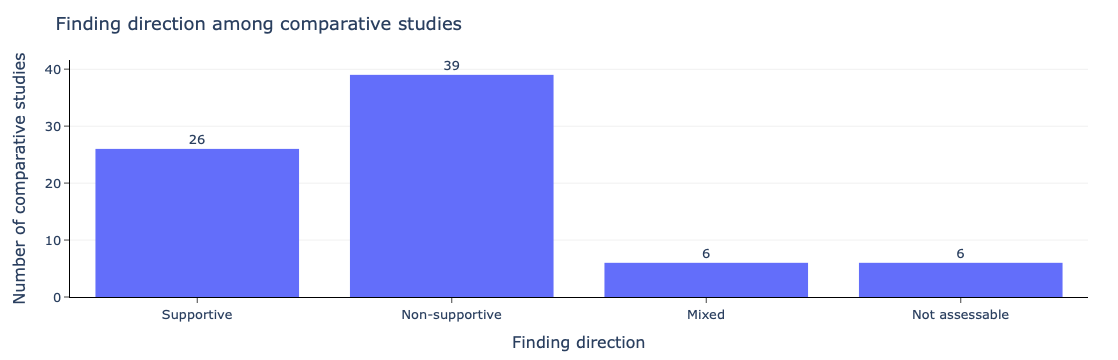

Saved interactive figure: outputs_two_axis/figures/finding_direction_comparative.html
Saved static figure: outputs_two_axis/figures/finding_direction_comparative.png


In [17]:
# Figure 3: Finding direction among comparative studies only
order = ["Supportive", "Non-supportive", "Mixed", "Not assessable"]
plot_df = finding_counts_comparative.copy()
plot_df["Finding direction"] = pd.Categorical(plot_df["Finding direction"], categories=order, ordered=True)
plot_df = plot_df.sort_values("Finding direction")

fig = px.bar(
    plot_df,
    x="Finding direction",
    y="Number of papers",
    text="Number of papers",
)
fig.update_traces(
    textposition="outside",
    hovertemplate="%{x}<br>Comparative studies: %{y}<br>Percent: %{customdata[0]}%<extra></extra>",
    customdata=plot_df[["Percent of comparative studies"]].to_numpy(),
    marker_line_width=0,
)
fig = apply_clean_plotly_style(fig, x_title="Finding direction", y_title="Number of comparative studies")
fig.update_layout(title="Finding direction among comparative studies", showlegend=False)
fig.show()
save_plotly(fig, "finding_direction_comparative")


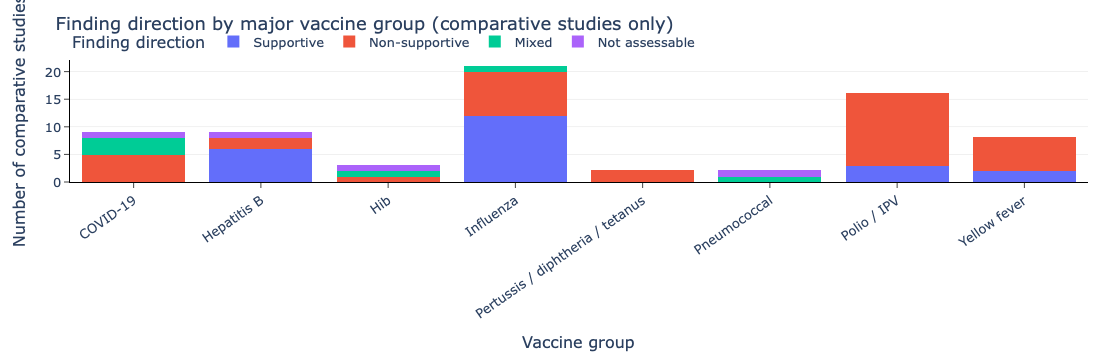

Saved interactive figure: outputs_two_axis/figures/finding_direction_by_major_vaccine_group.html
Saved static figure: outputs_two_axis/figures/finding_direction_by_major_vaccine_group.png


In [18]:
# Figure 4: Finding direction by major vaccine group (comparative studies only)
top_vaccines = (
    comparative_df["Vaccine_group"]
    .value_counts()
    .head(8)
    .index
    .tolist()
)

stacked = (
    comparative_df[comparative_df["Vaccine_group"].isin(top_vaccines)]
    .pivot_table(
        index="Vaccine_group",
        columns="Finding_direction",
        values="Study ID",
        aggfunc="count",
        fill_value=0,
    )
)

col_order = ["Supportive", "Non-supportive", "Mixed", "Not assessable"]
stacked = stacked[[c for c in col_order if c in stacked.columns]].reset_index()

long_df = stacked.melt(
    id_vars="Vaccine_group",
    var_name="Finding direction",
    value_name="Number of papers"
)

fig = px.bar(
    long_df,
    x="Vaccine_group",
    y="Number of papers",
    color="Finding direction",
)
fig.update_traces(
    hovertemplate="Vaccine group: %{x}<br>Finding: %{fullData.name}<br>Studies: %{y}<extra></extra>",
    marker_line_width=0,
)
fig = apply_clean_plotly_style(fig, x_title="Vaccine group", y_title="Number of comparative studies")
fig.update_layout(
    title="Finding direction by major vaccine group (comparative studies only)",
    barmode="stack",
    xaxis_tickangle=-35,
)
fig.show()
save_plotly(fig, "finding_direction_by_major_vaccine_group")

stacked.to_csv(TABLE_DIR / "finding_direction_by_major_vaccine_group_table.csv", index=False)


In [ ]:
# Figure 5: Finding direction by vaccine group, split by comparison type
top_vaccines = (
    comparative_df["Vaccine_group"]
    .value_counts()
    .head(8)
    .index
    .tolist()
)

plot_df = (
    comparative_df[comparative_df["Vaccine_group"].isin(top_vaccines)]
    .groupby(["Vaccine_group", "Comparison_type", "Finding_direction"], as_index=False)["Study ID"]
    .count()
    .rename(columns={"Study ID": "Number of papers"})
)

plot_df["Comparison_type"] = pd.Categorical(
    plot_df["Comparison_type"],
    categories=["Formal NI / equivalence", "Comparative, not formal NI"],
    ordered=True,
)
plot_df["Finding_direction"] = pd.Categorical(
    plot_df["Finding_direction"],
    categories=["Supportive", "Non-supportive", "Mixed", "Not assessable"],
    ordered=True,
)
plot_df = plot_df.sort_values(["Comparison_type", "Vaccine_group", "Finding_direction"])

fig = px.bar(
    plot_df,
    x="Vaccine_group",
    y="Number of papers",
    color="Finding_direction",
    facet_col="Comparison_type",
    category_orders={
        "Comparison_type": ["Formal NI / equivalence", "Comparative, not formal NI"],
        "Finding_direction": ["Supportive", "Non-supportive", "Mixed", "Not assessable"],
    },
)
fig.update_traces(
    hovertemplate="Vaccine group: %{x}<br>Finding: %{fullData.name}<br>Studies: %{y}<extra></extra>",
    marker_line_width=0,
)
fig = apply_clean_plotly_style(fig, x_title="Vaccine group", y_title="Number of comparative studies")
fig.update_layout(
    title="Finding direction by vaccine group, split by comparison type",
    barmode="stack",
)
fig.update_xaxes(tickangle=-35)

for annotation in fig.layout.annotations:
    annotation.text = annotation.text.replace("Comparison_type=", "")

fig.show()
save_plotly(fig, "finding_direction_by_vaccine_split_by_comparison_type")

plot_df.to_csv(TABLE_DIR / "finding_direction_by_vaccine_split_by_comparison_type_table.csv", index=False)

In [19]:
# Save cleaned datasets
analysis_df.to_csv(TABLE_DIR / "cleaned_analysis_dataset_all_rows.csv", index=False)
primary_df.to_csv(TABLE_DIR / "cleaned_analysis_dataset_primary_only.csv", index=False)
comparative_df.to_csv(TABLE_DIR / "cleaned_analysis_dataset_comparative_only.csv", index=False)
print("Saved cleaned datasets and tables.")
print("Tables folder:", TABLE_DIR.resolve())
print("Figures folder:", FIG_DIR.resolve())


Saved cleaned datasets and tables.
Tables folder: /Users/oliviawilko/Documents/Data Science/Global Helth/Impact First/outputs_two_axis/tables
Figures folder: /Users/oliviawilko/Documents/Data Science/Global Helth/Impact First/outputs_two_axis/figures


## Notes

- `primary_df` remains the operational set of all non-review records.
- The added evidence-strength fields are pragmatic review-level proxies rather than formal risk-of-bias judgements.
- `Comparator_rigor` is intentionally conservative: it separates direct full-dose comparisons from looser product/device/history-based comparisons.
- `Meta_analysis_readiness` and `Meta_analysis_barrier` are feasibility aids for synthesis planning, not hard yes/no verdicts on whether a meta-analysis should be attempted.
